# Exploring Trends in NYC Career and Technical Education Programs

#### Team Number: 4
#### Team Members: Md Sidick, Andrew Ingersoll, Rene Navarrete

# Introduction
We chose to analyze the Career Technical Education (CTE) data from the years 2016-2020 to determine trends between enrollment, industry partners, and industry sectors. Career Technical Education is a program in many high schools that provides students with the opportunity to gain technical skills and knowledge in a specific field of study and allow them to gain industry experience. Understanding trends in the industry sectors and the number of industry partners is important for schools to make informed decisions about the specific courses and industries they wish to offer.

In [12]:
import pandas as pd
from api_keys import nyc_open_data_key
import seaborn as sns
import matplotlib.pyplot as plt
from sodapy import Socrata

# Retrieving Data

In [13]:
baseUrl = 'data.cityofnewyork.us'
time = 60 #timeout in seconds
datasets=["yg8h-c8c7","v4se-2t5p","r9z2-6j3f","gyjk-fbss"] #list of dataset ids
years = ["2016-2017","2017-2018","2018-2019","2019-2020"]
all_dfs = [] #all dataframes will be stored here
client = Socrata(baseUrl,nyc_open_data_key, timeout=time ) #App Token Key 

#Ensuring enrolled_student_counts, number_of_industry_partners, and industry_of_the_cte_program are not null (filter)
where_filter = """
enrolled_student_counts IS NOT NULL
AND number_of_industry_partners IS NOT NULL
AND industry_cluster IS NOT NULL
""" 

### Filter Explanation
#### Enrolled student counts is one of our main metrics and thus, it is important to have values that are not null
#### Number of industry partners is another metric that will help make connections to industry connections with enrollment and it is important to have it not be null
#### Industry of the CTE program is how we will be grouping together the data with enrollment and is needed to be not null

In [14]:
for i in range(len(datasets)): #grab each dataset, add a year column, and append to a list
    results = client.get(
        datasets[i],
        where=where_filter,
        limit=2000
    )

    df = pd.DataFrame.from_records(results)
    df["year"] = years[i]
    all_dfs.append(df)

combined_df = pd.concat(all_dfs, ignore_index=True) #combine all dataframes

combined_df.to_csv("combined_cte_data.csv", index=False) #final dataframe saved as csv

print(combined_df.head())

      dbn                                        school_name  \
0  02M135  The Urban Assembly School for Emergency Manage...   
1  02M139  Stephen T. Mather Building Arts & Craftsmanshi...   
2  02M280     Manhattan Early College School for Advertising   
3  02M282                       Urban Assembly Maker Academy   
4  02M282                       Urban Assembly Maker Academy   

   cte_designated_high_school program_cip_code  \
0                        True           439999   
1                        True           469999   
2                        True           110899   
3                        True           110201   
4                        True           110899   

                                      program_name  \
0          Security and Protective Services, Other   
1                       Construction Trades, Other   
2  Computer Software and Media Applications, Other   
3         Computer Programming/Programmer, General   
4  Computer Software and Media Applications,

# Cleaning Data

In [15]:
df = pd.read_csv("combined_cte_data.csv") #set df to the combined data

#look at data to determine what must be cleaned
print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())

#drop duplicates as duplicates will skew the analysis
df.drop_duplicates(inplace=True)

#clean column names to remove extra spaces and make lowercase
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("-", "_")

# create new column using one of the existing columns 
df["staff_attending"] = df["number_of_school_staff"]

# fill missing values in new columns w/ values from old column
df["staff_attending"] = df["staff_attending"].fillna(df["number_of_staff_attending"])

#remove old columns
df.drop(columns=["number_of_school_staff", "number_of_staff_attending"], inplace=True)

#remove extra spaces from columns (for columns with strings)
text_cols = df.select_dtypes(include="object").columns

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

#make sure all columns are numeric (for columns with numbers)
df["enrolled_student_counts"] = pd.to_numeric(df["enrolled_student_counts"], errors="coerce")
df["number_of_industry_partners"] = pd.to_numeric(df["number_of_industry_partners"], errors="coerce")
df["staff_attending"] = pd.to_numeric(df["staff_attending"], errors="coerce")

# remove null values from rows vital to analysis and grouping (will skew the analysis)
df.dropna(subset=[
    "enrolled_student_counts",
    "number_of_industry_partners",
    "industry_cluster",
    "year"
], inplace=True)

#remove rows with negatives (negatives logically should not exist in the data)
df = df[df["enrolled_student_counts"] >= 0]
df = df[df["number_of_industry_partners"] >= 0]
df = df[df["staff_attending"] >= 0]

#check the cleaned data to make sure it looks good
print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())

#save cleaned data
df.to_csv("cleaned_cte_data.csv", index=False)

(1137, 13)
      dbn                                        school_name  \
0  02M135  The Urban Assembly School for Emergency Manage...   
1  02M139  Stephen T. Mather Building Arts & Craftsmanshi...   
2  02M280     Manhattan Early College School for Advertising   
3  02M282                       Urban Assembly Maker Academy   
4  02M282                       Urban Assembly Maker Academy   

   cte_designated_high_school  program_cip_code  \
0                        True            439999   
1                        True            469999   
2                        True            110899   
3                        True            110201   
4                        True            110899   

                                      program_name  \
0          Security and Protective Services, Other   
1                       Construction Trades, Other   
2  Computer Software and Media Applications, Other   
3         Computer Programming/Programmer, General   
4  Computer Software and Me

C:\Users\owasi\AppData\Local\Temp\ipykernel_23792\1636289506.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


# Analyzing Data

In [16]:
df = pd.read_csv("cleaned_cte_data.csv")

print(df.describe())

       program_cip_code  number_of_industry_partners  enrolled_student_counts  \
count       1137.000000                  1137.000000              1137.000000   
mean      341520.021108                     3.574318               236.114336   
std       183231.738886                     3.246066               250.362074   
min        10000.000000                     0.000000                 0.000000   
25%       120503.000000                     2.000000                96.000000   
50%       460201.000000                     3.000000               174.000000   
75%       510603.000000                     4.000000               311.000000   
max       521902.000000                    36.000000              3232.000000   

       staff_attending  
count      1137.000000  
mean          8.311346  
std           7.013053  
min           0.000000  
25%           3.000000  
50%           7.000000  
75%          12.000000  
max          36.000000  


### Summary Statistics
Average student enrollment is around 236 students per year. The standard deviation is very high at 250, suggesting some programs have much higher student enrollment than others. The max is 3232 and the min is 0, suggesting that some programs have no students enrolled into it, while others have an incredibly high number of students.

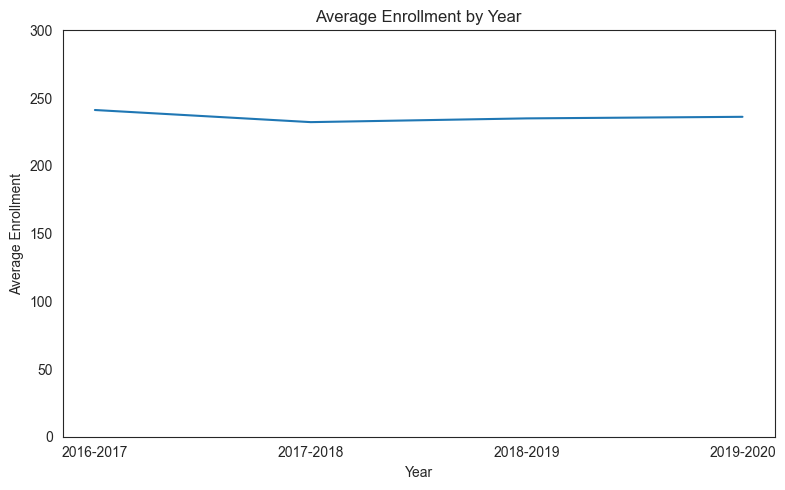

In [17]:
sns.set_style("white")

#group by year and calculate average enrollment
plt.figure(figsize=(8,5))
sns.lineplot(
    data=df,
    x="year",
    y="enrolled_student_counts",
    estimator="mean",
    errorbar=None
)
plt.title("Average Enrollment by Year") #plot title
plt.ylim(0, 300) #y-axis limits
plt.ylabel("Average Enrollment") #axis titles
plt.xlabel("Year")
plt.tight_layout()
plt.show()

### Enrollment Trends Over Time
Although there isn't much change in the enrollment numbers over time, there was a slight dip in 2017-2018 with a recovery the year after. However, the change in enrollment numbers is not very significant due to how small the difference is and could be attributed to fluctuations in school enrollment.

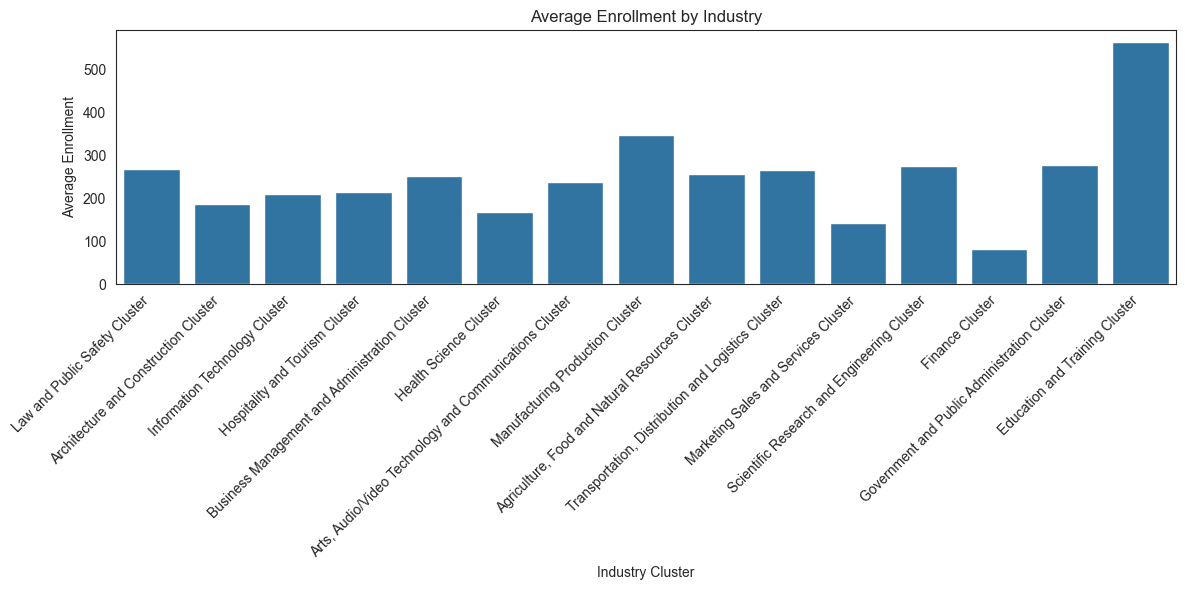

In [18]:
#enrollment by industry
plt.figure(figsize=(12,6))
sns.barplot(
    data=df,
    x="industry_cluster",
    y="enrolled_student_counts",
    estimator="mean",
    errorbar=None
)
plt.xticks(rotation=45, ha="right")
plt.title("Average Enrollment by Industry")
plt.ylabel("Average Enrollment")
plt.xlabel("Industry Cluster")
plt.tight_layout()
plt.show()

### Enrollment by Industry
According to the graph, Education and Training is the largest industry in terms of enrollment. This may be due to how the industry cluster is defined in the data. This is also a culmination of all four years, meaning Education and Training has a higher enrollment on average than the other industries for the entire period. 

Industries such as Information Technology and Scientific Research and Engineering have lower or about equal enrollment to industries such as Business Management and Arts, Audio/Video Technology and Communications, possibly suggesting that other industries other than STEM also have good exposure in CTE programs.  

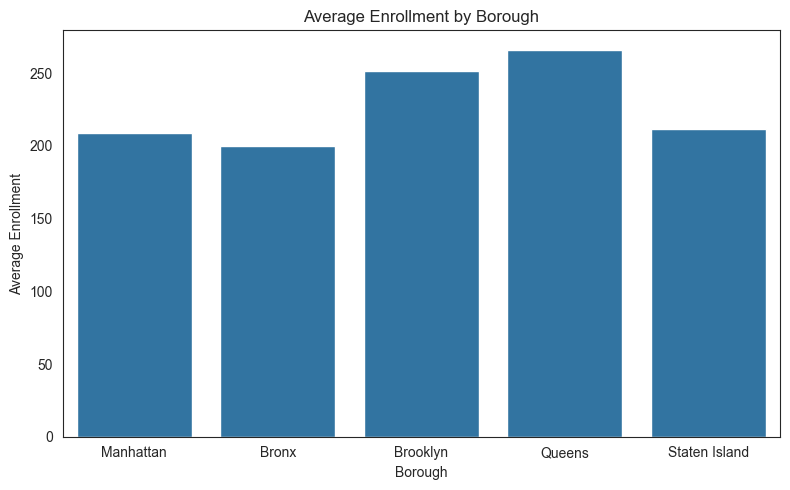

In [19]:
#enrollment by borough
df["borough_code"] = df["dbn"].str[2] #grab borough code using dbn (the 3rd character signifies borough)

borough_map = { #borough mapping
    "M": "Manhattan",
    "X": "Bronx",
    "K": "Brooklyn",
    "Q": "Queens",
    "R": "Staten Island"
}

df["borough"] = df["borough_code"].map(borough_map)

plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x="borough",
    y="enrolled_student_counts",
    estimator="mean",
    errorbar=None
)

plt.title("Average Enrollment by Borough")
plt.ylabel("Average Enrollment")
plt.xlabel("Borough")
plt.tight_layout()
plt.show()

### Enrollment by Borough
The graph shows the average enrollment of CTE programs across different boroughs. Differences in enrollment may reflect variations in school size, program availability, or student demand across boroughs.

This analysis helps provide insight into how CTE program participation differs geographically within New York City. There is a clear focus on Queens and Brooklyn, but the Bronx is falling behind in comparision to the other boroughs.

However, it is important to note that this data represents the location of the schools, not necessarily where the students live. Students may attend schools outside of their home borough, so these results reflect program location rather than the geographic distribution of students.

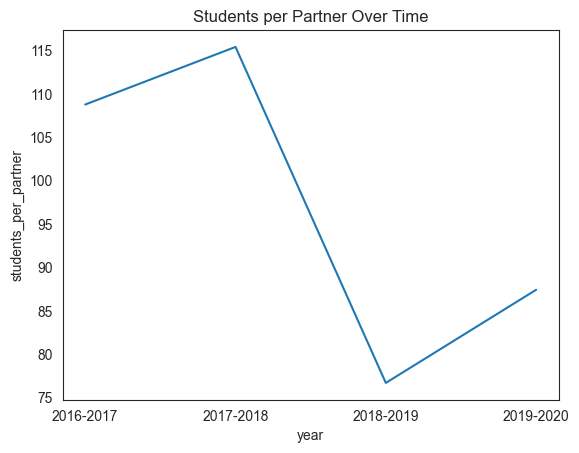

In [20]:
#calculated column for students per industry partner
df = df[df["number_of_industry_partners"] > 0]

df["students_per_partner"] = df["enrolled_student_counts"] / df["number_of_industry_partners"]

#students per industry partner over time
sns.lineplot(
    data=df,
    x="year",
    y="students_per_partner",
    estimator="mean",
    errorbar=None
)
plt.title("Students per Partner Over Time")
plt.show()

### Students per Industry Partner
A new column was created to calculate the number of students per industry partner. Rows with zero industry partners were removed before creating the students_per_partner column to avoid division errors. This ensures the calculated values are meaningful and consistent.

Higher values indicate that each partner is associated with more students, which may suggest limited capacity or strain on available partnerships. Lower values indicate that students may receive more support due to a higher number of industry partners.

According to the graph, there is a noticeable decrease from 2017–2018 to 2018–2019. Since overall enrollment did not change significantly, this decrease may be due to an increase in the number of industry partners during that period, allowing for better distribution of students across partners.

There is a slight increase again in 2019–2020, which may suggest a reduction in industry partnerships or a shift in how partnerships were structured.

                             enrolled_student_counts  \
enrolled_student_counts                     1.000000   
number_of_industry_partners                 0.033085   
staff_attending                            -0.092474   

                             number_of_industry_partners  staff_attending  
enrolled_student_counts                         0.033085        -0.092474  
number_of_industry_partners                     1.000000         0.012272  
staff_attending                                 0.012272         1.000000  


<Axes: xlabel='number_of_industry_partners', ylabel='enrolled_student_counts'>

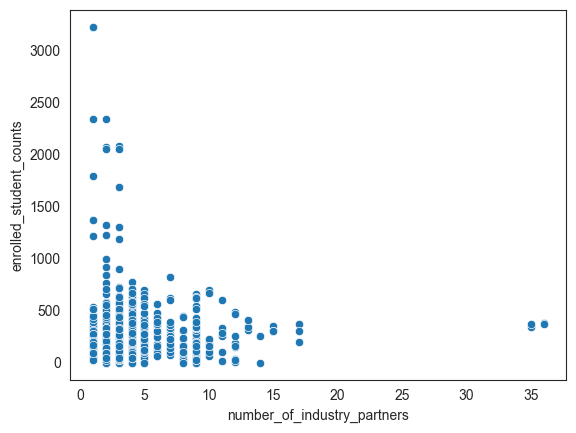

In [21]:
#correlation & scatterplot between enrolled students, number of industry partners, and staff attending
print(df[[
    "enrolled_student_counts",
    "number_of_industry_partners",
    "staff_attending"
]].corr())

sns.scatterplot(
    data=df,
    x="number_of_industry_partners",
    y="enrolled_student_counts"
)


### Correlation Analysis 
The correlation shows there is no strong relationship between variables in the dataset. The correlation between enrolled student counts and number of industry partners is approximately 0.03, which is very close to zero. This indicates that the number of industry partners does not significantly affect student enrollment.

Similarly, the correlation between enrolled student counts and staff attending is slightly negative at around -0.09, but still close to 0. This suggests that staff participation is not strongly associated with enrollment levels.

The correlation between number of industry partners and staff attending is also close to zero, indicating little to no relationship between these variables.

Overall, these results suggest that factors such as industry partnerships and staff involvement alone do not strongly determine student enrollment in CTE programs. Other factors, such as program popularity, program availability, or how programs are structured, may also play a role in determining student enrollment.

### Insights & Conclusion
This analysis provides insight into how CTE programs function across New York City and highlights areas that may need further attention from policymakers.

First, the high variability in enrollment suggests that some programs are significantly larger than others. This may indicate an uneven distribution of resources, where certain programs or schools may be receiving a high amount of support, but other schools require more funding and assistance. Policymakers may consider evaluating how programs are distributed and whether resources are being allocated efficiently across schools.

Second, the weak correlation between industry partnerships and student enrollment suggests that simply increasing the number of industry partners may not directly lead to higher participation. Instead, policymakers may need to focus on the quality and structure of these partnerships, ensuring the opportunities provided by industry partnerships are aligned with the needs of students.

Additionally, differences in enrollment across industry clusters may be influenced by how programs are categorized and offered. Some industries may appear more popular due to broader classification or greater availability. Policymakers should review how programs are labeled and ensure consistency across schools to better understand student interests.

From a geographical perspective, differences across boroughs may reflect variations in access to programs. However, since students can attend schools outside their home borough, this highlights the importance of accessibility and transportation when considering program expansion.

Overall, this analysis suggests that improving CTE participation is not just about increasing partnerships or expanding programs, but about ensuring equal access to resources for all students. Policymakers should consider how to address the challenges of uneven distribution and ensure that all students have access to the resources they need to succeed.

### Challenges Faced & Lessons Learned
- Dealing with large data sets can be a challenge, especially when it comes to data cleaning. It can get messy and difficult while trying not to lose any data
- Data cleaning, although it is time-consuming, is necessary with how some datasets are structured
- Figuring out what exact variables and how to connect and analyze them was a challenge. Thinking of what conclusions can be drawn from the data and what questions can be answered proved to be difficult